In [170]:
import numpy as np
import pandas as pd


In [171]:
df=pd.read_csv('/content/dirty_dataset.csv')

In [172]:
df.head()

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
0,12369,Hasan D.,200.0,35149,2023-05-30,SALES,Man,America,Sylhet,118.4,0,Good value for money.,219.18,NaN,0
1,7361,Grace P.,NaN,77836,2017-02-27,Engineering,FEMALE,America,Chittagong,71kg,True,Product met all expectations.,329.26,NaN,0
2,3446,Eve D.,20.0,35404,2022-01-18,hr,male,BANGLADESH,Chitagong,98.7,False,Very satisfied with the quality.,438.6,NaN,0
3,18416,Diana E.,47.0,107375,2017-04-15,Marketing,Male,U.K.,Khulna,NaN,false,Delivery was fast and packaging great.,238.03,NaN,0
4,13677,Ira W.,64.0,55962,2021-11-02,SALES,F,United Kingdom,Dhaka,83.5,false,Would buy again without hesitation.,9.4,NaN,0


In [173]:
df.shape


(20300, 15)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20300 entries, 0 to 20299
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          20300 non-null  int64  
 1   name                 20300 non-null  object 
 2   age                  19679 non-null  float64
 3   salary               19690 non-null  object 
 4   join_date            19490 non-null  object 
 5   department           19443 non-null  object 
 6   gender               18668 non-null  object 
 7   country              19692 non-null  object 
 8   city                 19696 non-null  object 
 9   weight_kg            19657 non-null  object 
 10  is_active            19714 non-null  object 
 11  review               18835 non-null  object 
 12  price                19854 non-null  object 
 13  weight_kg_duplicate  0 non-null      float64
 14  target               20300 non-null  int64  
dtypes: float64(2), int64(2), object(11)


In [175]:
df.dtypes

,0
employee_id,int64
name,object
age,float64
salary,object
join_date,object
department,object
gender,object
country,object
city,object
weight_kg,object


In [176]:
df.describe()

,employee_id,age,weight_kg_duplicate,target
count,20300.000000,19679.000000,0.0,20300.000000
mean,9903.786305,45.457696,NaN,0.049655
std,5822.475853,63.075321,NaN,0.217237
min,1.000000,-5.000000,NaN,0.000000
25%,4850.750000,29.000000,NaN,0.000000
50%,9908.500000,41.000000,NaN,0.000000
75%,14944.250000,54.000000,NaN,0.000000
max,20000.000000,999.000000,NaN,1.000000


In [177]:
df1=df.copy()

## **Task 01 Missing Values (NaN, Empty Strings)**


* Run df.isnull().sum() to count missing values per column.
* Numeric columns (age, salary, price, weight_kg): fill with median.

* Categorical columns (department, gender, country, city): fill with mode.
*  Date column (join_date): forward fill or fill with most frequent date.

* Review column: fill with No Review.
* is_active: fill with False (conservative approach).

* Verify: run df.isnull().sum() again — all should be 0.










In [178]:
df.isnull().sum()

,0
employee_id,0
name,0
age,621
salary,610
join_date,810
department,857
gender,1632
country,608
city,604
weight_kg,643


In [179]:
df.isnull().mean() * 100

,0
employee_id,0.000000
name,0.000000
age,3.059113
salary,3.004926
join_date,3.990148
department,4.221675
gender,8.039409
country,2.995074
city,2.975369
weight_kg,3.167488


In [180]:
nummeric_col=['age', 'salary', 'price', 'weight_kg']
replace_mp={
    'salary':'$',
    'weight_kg':'kg',
    'price': '$'
}


In [181]:
for col , symbol in replace_mp.items():
  df[col]=pd.to_numeric(
      df[col].astype(str).str.replace(symbol,'',regex=False),
      errors='coerce')

In [182]:
#Numeric columns (age, salary, price, weight_kg): fill with median.
for col in nummeric_col:
  df[col]=df[col].fillna(df[col].median())

In [183]:
#Categorical columns (department, gender, country, city): fill with mode.
Cal_cols=['department', 'gender', 'country','city']
for col in Cal_cols:
  df[col]=df[col].fillna(df[col].mode()[0])

In [184]:
#Date column (join_date): forward fill or fill with most frequent date.
df['join_date'] =df['join_date'].ffill()

In [185]:
#Review column: fill with No Review.
df['review']=df['review'].fillna('No Review')

In [186]:
#is_active: fill with False (conservative approach).
df['is_active']=df['is_active'].fillna('False')

In [187]:
df.isnull().sum()

,0
employee_id,0
name,0
age,0
salary,0
join_date,0
department,0
gender,0
country,0
city,0
weight_kg,0


In [188]:
df.dtypes

,0
employee_id,int64
name,object
age,float64
salary,float64
join_date,object
department,object
gender,object
country,object
city,object
weight_kg,float64


# **Interpretation**


* Few missing values (<5%) → usually safe to drop.
* Numeric columns → Mean/Median.
*  Categorical columns → Mode.
*  Time series → Forward Fill / Backward Fill.






# 🧹 Data Cleaning — Missing Value Handling

### Objective

Missing/Null values গুলোকে column-এর data type এবং data-এর nature অনুযায়ী appropriate method ব্যবহার করে handle করা হয়েছে।

###Numeric Columns → Median

**Columns:** `age`, `salary`, `price`, `weight_kg`

প্রতিটি numeric column-এর missing values সেই column-এর **median** দিয়ে fill করেছি।

###Categorical Columns → Mode

**Columns:** `department`, `gender`, `country`, `city`

প্রতিটি categorical column-এর missing values **mode (most frequent value)** দিয়ে fill করেছি।

###Join Date → Forward Fill (`ffill`)

**Column:** `join_date`

`join_date` column-এর missing values-এর জন্য **forward fill (`ffill`)** ব্যবহার করেছি।

অর্থাৎ, কোনো row-তে `join_date` missing থাকলে তার আগের available date দিয়ে সেটি fill করা হয়েছে।

###Boolean Column → False

**Column:** `is_active`

Missing values-গুলোকে conservative approach হিসেবে **False** দিয়ে fill করেছি।

## 📌 Quick Summary

| Column Type | Missing Value Handling |
| ----------- | ---------------------- |
| Numeric     | Median                 |
| Categorical | Mode                   |
| Join Date   | Forward Fill (`ffill`) |
| Boolean     | False                  |

### 🔑 Rule to Remember

**Numeric → Median**
**Categorical → Mode**
**Join Date → Forward Fill**
**Boolean → False**


## **Task 02:Duplicate Rows**

* Run df.duplicated().sum() to count duplicates.
* Preview duplicates: df[df.duplicated()]
* Remove duplicates: df.drop_duplicates(inplace=True)
* Verify: compare df.shape before and after.





In [189]:
#Run df.duplicated().sum() to count duplicates.
df.duplicated().sum()

np.int64(291)

In [190]:
#Preview duplicates
df[df.duplicated(keep=False)]

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
0,12369,Hasan D.,200.0,35149.0,2023-05-30,SALES,Man,America,Sylhet,118.4,0,Good value for money.,219.18,NaN,0
8,13108,Diana V.,43.0,88859.0,21/07/2016,Marketing,Male,United States,Khulna,73.8,True,good,430.17,NaN,0
72,7852,Alice X.,36.0,83430.0,05-Oct-2013,hr,FEMALE,USA,Rajshahi,93.6,1,ok,374.55,NaN,0
89,16626,Hasan C.,39.0,98588.0,04-Mar-2018,engineering,FEMALE,United Kingdom,Slyhet,72.9,True,Good value for money.,61.23,NaN,0
115,16035,Hasan V.,53.0,-500.0,2017-03-01,Marketing,female,BANGLADESH,Chittagong,48.2,False,Product met all expectations.,385.13,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20110,13509,Charlie S.,34.0,106326.0,2016-06-20,Finace,Man,U.S.A,Slyhet,112.3,False,fine,340.03,NaN,0
20140,2388,Eve A.,35.0,98091.0,2017-04-22,SALES,M,America,Slyhet,90.4,False,Good value for money.,451.34,NaN,0
20154,2689,John O.,46.0,45615.0,2019/12/04,hr,F,usa,Rajshahi,118.0,False,Would buy again without hesitation.,341.28,NaN,0
20173,5188,Charlie J.,46.0,97030.0,2017-04-03,HR,Male,BANGLADESH,Chittagong,73.0,True,bad,419.32,NaN,0


In [191]:
#Remove duplicates
df.drop_duplicates(inplace=True)

In [192]:
#Verify: compare df.shape before and after
df.shape

(20009, 15)

# **Interpretation**

* Duplicate records create bias.
* Same customer appearing multiple times can distort analysis.



# 🧹 Data Cleaning — Duplicate Rows
##Objective

Dataset-এর duplicate rows identify করে unnecessary duplicate records remove করা হয়েছে।

Steps Performed

# **Count Duplicates**

প্রথমে dataset-এ কতগুলো duplicate row আছে তা count করেছি।


# **Preview Duplicates**

Duplicate rows গুলো identify ও preview করেছি।


# **Remove Duplicates**

Unnecessary duplicate rows remove করে প্রতিটি duplicate record-এর প্রথম occurrence রাখা হয়েছে।


# **Verify**
Duplicate removal-এর আগে ও পরে df.shape compare করে dataset-এর row count পরিবর্তন verify করেছি।

# **📌 Summary**

Count → Preview → Remove → Verify

এই process-এর মাধ্যমে dataset থেকে duplicate rows successfully remove করা হয়েছে এবং final dataset-এর structure verify করা হয়েছে।

## **Task 03 Duplicate IDs**


* Count: df[employee_id].duplicated().sum()

*  View: df[[employee_id].duplicated(keep=False)]

*  keep first occurrence — df.drop_duplicates(subset=[employee_id], keep=first)
*  Verify: assert df[&#39;employee_id&#39;].duplicated().sum() == 0



In [193]:
df['employee_id'].duplicated().sum()

np.int64(208)

In [194]:
df[df['employee_id'].duplicated(keep=False)]

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
29,250,Frank U.,56.0,90635.0,2013-05-12,Sales,male,Bangladesh,Dhaka,107.3,0,Would buy again without hesitation.,342.24,NaN,1
40,49,John L.,58.0,50810.0,2024-07-22,hr,FEMALE,U.K.,Dhakka,108.8,False,"Excellent product, highly recommend!",83.46,NaN,0
75,48,Ira E.,0.0,101013.0,2013-08-28,engineering,MALE,BD,Dhakka,115.0,0,Good value for money.,318.78,NaN,0
196,436,Charlie S.,29.0,54295.0,2020-08-27,Mrketing,M,us,Chittagongg,75.9,False,Product met all expectations.,265.25,NaN,0
270,86,Bob U.,36.0,61688.0,2012/11/23,engineering,M,bd,Sylhet,91.7,False,na,167.05,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20016,207,Bob M.,63.0,73657.0,2013-10-08,Mrketing,M,USA,Rajshahi,125.5,False,Very satisfied with the quality.,167.18,NaN,0
20072,435,Charlie U.,31.0,112727.0,2016-04-15,engineering,MALE,U.K.,Rajshahi,119.0,1,Good value for money.,242.44,NaN,0
20104,427,Frank U.,33.0,35686.0,2014-03-21,Mrketing,M,usa,Rajshahi,73.8,True,Good value for money.,396.43,NaN,0
20267,35,Eve L.,55.0,40160.0,2015-12-13,Finance,Male,U.K.,Dhaka,61.0,True,Very satisfied with the quality.,106.40,NaN,0


In [195]:
df.drop_duplicates(
    subset=['employee_id'],keep='first', inplace=True
)

In [196]:
assert df['employee_id'].duplicated().sum() == 0

## **🧹 Data Cleaning — Duplicate Employee IDs**

### Objective

`employee_id` column-এ থাকা duplicate Employee IDs identify করে প্রতিটি Employee-এর প্রথম occurrence রাখা হয়েছে এবং duplicate IDs remove করা হয়েছে।

### Steps Performed

**Count Duplicate Employee IDs**

প্রথমে `employee_id` column-এ কতগুলো duplicate value আছে তা count করেছি।

**View Duplicate Employee IDs**

Duplicate Employee IDs-এর সব occurrence preview করেছি।

**Keep First Occurrence**

একই `employee_id` একাধিকবার থাকলে **প্রথম occurrence রাখা** হয়েছে এবং পরের duplicate records remove করা হয়েছে।

**Verify**

Duplicate Employee IDs successfully remove হয়েছে কিনা `assert` ব্যবহার করে verify করেছি।

### 📌 Summary

**Count → View → Keep First → Remove → Verify**

**Rule:** প্রতিটি `employee_id` dataset-এ unique থাকবে এবং duplicate হলে প্রথম occurrence রাখা হবে।


# **Task 04 Wrong Date Formats**

* Check dtype: df[join_date].dtype — will be object.
* Convert: pd.to_datetime(df[join_date], infer_datetime_format=True, errors=coerce)
* errors=coerce turns unrecognized formats into NaT.
* Handle NaT values: fill with median date.
* Standardize output: df[join_date].dt.strftime(%Y-%m-%d)
*  Verify dtype: df[join_date].dtype — should be datetime64.




In [197]:
df['join_date'].dtypes

dtype('O')

In [198]:
df['join_date']=pd.to_datetime(df['join_date'],infer_datetime_format=True,errors='coerce')

/tmp/ipykernel_552/1654753125.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['join_date']=pd.to_datetime(df['join_date'],infer_datetime_format=True,errors='coerce')


In [199]:
df['join_date'].dtypes

dtype('<M8[ns]')

In [200]:
df['join_date'].isnull().sum()

np.int64(2574)

In [201]:
df['join_date']=df['join_date'].fillna(df['join_date'].median())

In [202]:
df['join_date'].isnull().sum()

np.int64(0)

In [203]:
df['join_date']=df['join_date'].dt.strftime('%Y-%m-%d')

## **📅 Task 04 — Wrong Date Formats**

### Objective

`join_date` column-এর বিভিন্ন ভুল date format identify করে সেগুলোকে standard datetime format-এ convert করা হয়েছে।

### Steps Performed

# **Check Data Type**

প্রথমে `join_date` column-এর data type check করেছি। এটি `object` type ছিল।

# **Convert to Datetime**

`join_date` column-কে Pandas datetime format-এ convert করেছি।


# ** Handle Invalid Date Formats**

`errors='coerce'` ব্যবহার করার ফলে যেসব date format Pandas recognize করতে পারেনি, সেগুলো `NaT` (Not a Time)-এ convert হয়েছে।

# **Handle NaT Values**

Conversion-এর পরে তৈরি হওয়া `NaT` values-গুলো **median date** দিয়ে fill করেছি।

# **Standardize Date Format**

Date values-গুলোকে `YYYY-MM-DD` format-এ standardize করেছি।

# **Verify Data Type**

শেষে আবার data type check করে নিশ্চিত করেছি যে `join_date` column datetime format-এ আছে।


### 📌 Summary

**Check → Convert → Handle Invalid Dates → Fill NaT → Standardize → Verify**

এর মাধ্যমে `join_date` column-এর inconsistent/invalid date formats clean করে একটি standardized datetime format-এ আনা হয়েছে।


## **Task 05 Numeric Stored as String**


* Check dtype: df[salary].dtype — will be object.

* salary: df[salary].str.replace( regex=False).astype(float)

* weight_kg: df[weight_kg].str.replace(&#39;kg&#39;, &#39;&#39;, regex=False).astype(float)
* price: same approach — strip $ then convert to float.

* Handle errors: pd.to_numeric(df[salary], errors=coerce)
* Verify: df.dtypes — all three columns should be float64.




In [204]:
df[['salary','weight_kg','price']].dtypes

,0
salary,float64
weight_kg,float64
price,float64


# 🧹 Task-05: Numeric Stored as String

**Task-05-এর numeric conversion-এর কাজগুলো আমি আগেই Task-01 (Missing Value Handling)-এর সময় করে ফেলেছিলাম।**

* `salary` → `$` remove করে `numeric/float` এ convert করেছি
* `weight_kg` → `kg` remove করে `numeric/float` এ convert করেছি
* `price` → `$` remove করে `numeric/float` এ convert করেছি
* `pd.to_numeric(..., errors='coerce')` ব্যবহার করে invalid value → `NaN` করেছি
* এরপর প্রয়োজন অনুযায়ী **median দিয়ে missing values fill** করেছি

**Note:** তাই Task-05 আলাদাভাবে নতুন করে করার প্রয়োজন হয়নি।


# **Task 06 Inconsistent Labels**


* Inspect: df[country].value_counts() to see all unique values.

* Build a mapping dictionary for country:

* country_map = {USA:United States,U.S.A : United States,us:United States,America:United States}

*  Apply: df[country] = df[country].map(country_map).fillna(df[country])
*  gender: df[gender].str.lower() then map to standard values.
* department: df[department].str.strip().str.title() then fix spellings.
* 35. Verify: run value_counts() on each column after fixing.




# **Task 07: Spelling Mistakes**


* Inspect: `df['city']`.value_counts() to find all misspelled cities.

*  Build correction dictionary:
* Same approach for department
*   Verify: `df['city']`.unique() — should only show correct city names.




In [205]:
df['country'].unique()

array(['America', 'BANGLADESH', 'U.K.', 'United Kingdom', 'UK', 'us',
       'United States', 'Bangladesh', 'usa', 'U.S.A', 'USA', 'bd', 'BD'],
      dtype=object)

In [206]:
country_map={
    'USA':'United States',
    'U.S.A':'United States',
    'usa':'United States',
    'us':'United States',
    'America':'United States',
    'United States ':'United States',
    'BANGLADESH':'Bangladesh',
    'Bangladesh ':'Bangladesh',
    'bd':'Bangladesh',
    'BD':'Bangladesh',
    'UK':'United Kingdom',
    'U.K.':'United Kingdom'
    }

In [207]:
df['country']=df['country'].map(country_map).fillna(df['country'])

In [208]:
df['country'].unique()

array(['United States', 'Bangladesh', 'United Kingdom'], dtype=object)

In [209]:
df['gender']=df['gender'].str.lower()

In [210]:
df['gender'].unique()

array(['man', 'female', 'male', 'f', 'woman', 'm'], dtype=object)

In [211]:
gender_map={
    'male':'Male',
    'm':'Male',
    'man':'Male',
    'M':'Male',
    'female':'Female',
    'f':'Female',
    'F':'Female',
    'woman':'Female'
}

In [212]:
df['gender']=df['gender'].map(gender_map).fillna(df['gender'])

In [213]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [214]:
df['department']=df['department'].str.strip().str.title()

In [215]:
df['department'].unique()

array(['Sales', 'Engineering', 'Hr', 'Marketing', 'Mrketing', 'Finace',
       'Finance'], dtype=object)

In [216]:
deparmet_map={
    'Mrketing':'Marketing',
    'Finace':'Finance'
}

In [217]:
df['department']=df['department'].map(deparmet_map).fillna(df['department'])

In [218]:
df['department'].unique()

array(['Sales', 'Engineering', 'Hr', 'Marketing', 'Finance'], dtype=object)

In [219]:
df['city'].unique()


array(['Sylhet', 'Chittagong', 'Chitagong', 'Khulna', 'Dhaka', 'Rajshahi',
       'Chittagongg', 'Slyhet', 'Dhakka', 'Rajshai', 'Dhka'], dtype=object)

In [220]:
city_map={
    'Sylhet':'Sylhet',
    'Slyhet':'Sylhet',
   'Chittagong':'Chattogram',
    'Chittagongg':'Chattogram',
    'Chitagong':'Chattogram',
    'Dhaka':'Dhaka',
    'Dhakka':'Dhaka',
    'Dhka':'Dhaka',
    'Khulna':'Khulna',
    'Khulna ':'Khulna',
    'Rajshai':'Rajshahi'

}

In [221]:
df['city']=df['city'].map(city_map).fillna(df['city'])

In [222]:
df['city'].unique()

array(['Sylhet', 'Chattogram', 'Khulna', 'Dhaka', 'Rajshahi'],
      dtype=object)

## 🧹 Task 06: Inconsistent Labels

এই Task-এ বিভিন্ন column-এর inconsistent বা ভিন্নভাবে লেখা label গুলো standardize করেছি।

* **country:** `value_counts()` দিয়ে unique values inspect করে mapping ব্যবহার করে USA, U.S.A, us, America → **United States** করেছি।
* **gender:** `.str.lower()` ব্যবহার করে সব value একই lowercase format-এ এনেছি এবং standard values অনুযায়ী ঠিক করেছি।
* **department:** `.str.strip().str.title()` দিয়ে extra spaces remove করে proper format-এ এনেছি এবং spelling ভুলগুলো ঠিক করেছি।

**Goal:** একই তথ্য যেন বিভিন্ন নামে বা format-এ না থাকে এবং dataset consistent থাকে।


## **Task 08 : Outliers**

* Explore: `df[salary]`.describe() to see min, max, mean, std.

* Visualize: `df[salary]`.plot(kind=&#39;box&#39;) or plt.boxplot(df[salary])

* Calculate IQR: Q1 = `df[salary]`.quantile(0.25), Q3 = `df[salary]`.quantile(0.75)
* IQR = Q3 - Q1
* Bounds: lower = Q1 - 1.5*IQR | upper = Q3 + 1.5*IQR

* Identify outliers: `df[df[salary]` > upper] or `df[df[salary]` < lower]
* Cap outliers: `df[salary] = df[salary]`.clip(lower, upper)

* Verify: run describe() again and compare max/min values.








In [223]:
df['salary'].describe()

,salary
count,1.980100e+04
mean,2.304154e+05
std,1.238438e+06
min,-5.000000e+02
25%,5.220200e+04
50%,7.440450e+04
75%,9.660600e+04
max,9.999999e+06


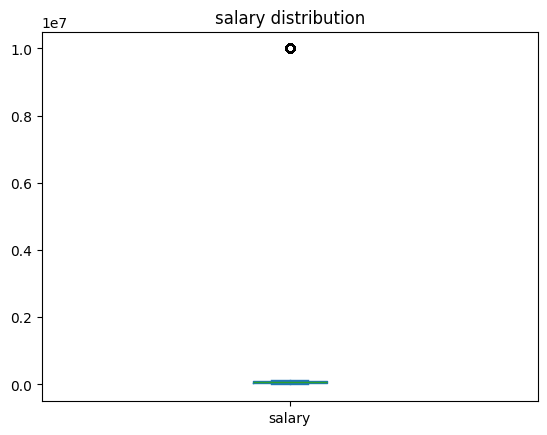

In [224]:
import matplotlib.pyplot as plt
df['salary'].plot(kind='box')
plt.title('salary distribution')
plt.show()

In [225]:
Q1=df['salary'].quantile(.25)
Q3=df['salary'].quantile(.75)
IQR=Q3-Q1

In [226]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

In [227]:
# Detect
outliers=df[
    (df['salary'] < lower) |
    (df['salary'] > upper)
]

In [228]:
# Cap
df['salary']=df['salary'].clip(lower,upper)

In [229]:
df['salary'].describe()

,salary
count,19801.00000
mean,74922.48245
std,28692.61617
min,-500.00000
25%,52202.00000
50%,74404.50000
75%,96606.00000
max,163212.00000


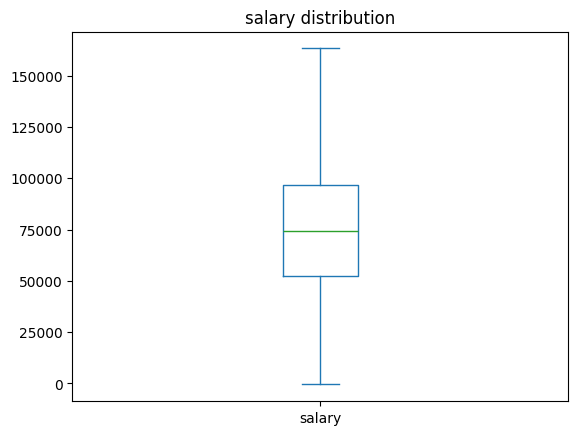

In [230]:
import matplotlib.pyplot as plt
df['salary'].plot(kind='box')
plt.title('salary distribution')
plt.show()

## **📊 Task 08: Outliers**

এই Task-এ `salary` column-এর outlier identify ও handle করেছি।

* `describe()` দিয়ে `min`, `max`, `mean`, `std` দেখে data explore করেছি।
* **Box Plot** ব্যবহার করে outlier visualize করেছি।
* **IQR Method** দিয়ে `Q1`, `Q3`, `IQR` এবং lower/upper bounds calculate করেছি।
* Bounds-এর বাইরে থাকা salary values-কে **outlier** হিসেবে identify করেছি।
* `clip()` ব্যবহার করে outlier values-কে lower ও upper bound-এর মধ্যে **cap** করেছি।
* শেষে আবার `describe()` চালিয়ে `min` ও `max` compare করে verify করেছি।

**Goal:** Extreme salary values-এর প্রভাব কমিয়ে dataset-কে more consistent করা।


# **Task 09 Invalid Values**


* Count invalid ages: `df[(df[age]` <  18) | (`df[age] > 65)]`.shape

* Set invalid ages to NaN: df.loc`[df[age] < 18, 'age']` = np.nan

* df.loc`[df[age] > 65, 'age']` = np.nan

*  Fill NaN with median: `df[age]`.fillna`(df[age]`.median(), inplace=True)
* Do the same for price: df.loc`[df[&price] < 0, price3 ]`= np.nan then fill.


* Verify: assert `(df[age] >= 18).all() and (df[age] <= 65).all()`




In [231]:
df[(df['age'] < 18) | (df['age'] > 65)].shape

(388, 15)

In [232]:
df.loc[(df['age'] < 18) | (df['age'] > 65),'age'] = np.nan

In [233]:
df['age']=df['age'].fillna(df['age'].median())

In [234]:
# Assert that all ages are within the 18-65 range
assert (df['age'] >= 18).all() and (df['age'] <= 65).all()

In [235]:
df['age'].dtype
df['age'].isna().sum()
df['age'].describe()

,age
count,19801.000000
mean,41.443412
std,13.522277
min,18.000000
25%,30.000000
50%,41.000000
75%,53.000000
max,65.000000


In [236]:
df[df['price'] < 0].shape

(390, 15)

In [237]:
df.loc[df['price'] < 0, 'price'] =np.nan

In [238]:
df['price']=df['price'].fillna(df['price'].median())

In [239]:
assert (df['price'] >= 0).all()

# 🧹 Task 09: Invalid Values

এই Task-এ `age` ও `price` column-এর invalid values identify করে ঠিক করেছি।

* **Age:** `18–65` range-এর বাইরে থাকা values → `NaN` করেছি।
* `NaN` values → **median** দিয়ে fill করেছি।
* **Price:** `0`-এর নিচের negative values → `NaN` করে median দিয়ে fill করেছি।
* শেষে `assert` ব্যবহার করে `age` valid range-এর মধ্যে আছে কিনা verify করেছি।

**Goal:** Dataset থেকে invalid values remove করে valid ও consistent data রাখা।


## **Task 10 Noisy Text (Reviews)**


* Inspect:`df[review].value_counts()` to identify noisy values.
*  Define noisy list: noisy = `[ok,bad,na,n/a,...,fine,not bad,ok ,ok]`

* Replace noisy values: `df[review] = df[review].replace(noisy, np.nan)`
* Also replace empty strings: `df[review].replace(&#39;&#39;, np.nan, inplace=True)`
* Fill NaN reviews with `No Review`.
* Verify: `df[review].str.split().str.len().value_counts()` — check word count distribution.




In [240]:
df['review'].unique()

array(['Good value for money.', 'Product met all expectations.',
       'Very satisfied with the quality.',
       'Delivery was fast and packaging great.',
       'Would buy again without hesitation.',
       'Excellent product, highly recommend!', 'good', 'na', '...',
       'ok ok', 'bad', 'No Review', 'ok', '.', 'fine', 'not bad'],
      dtype=object)

In [241]:
df['review']=df['review'].value_counts()


In [242]:
noisy = ['ok', 'bad', 'na', 'n/a', '...', 'fine', 'not bad', 'ok ', 'ok']

In [243]:
df['review']=df['review'].replace(noisy,np.nan)


In [244]:
df['review']=df['review'].fillna('No Review')

In [245]:
df['review'].str.split().str.len().value_counts()

,count
review,
2,19801


# 🧹 Task 10: Noisy Text (Reviews)

এই Task-এ `review` column-এর noisy ও invalid text values clean করেছি।

* `value_counts()` দিয়ে noisy values identify করেছি।
* `ok`, `bad`, `na`, `n/a`, `fine`, `not bad` ইত্যাদি noisy values → `NaN` করেছি।
* Empty string (`''`) → `NaN` করেছি।
* সব `NaN` review → **`No Review`** দিয়ে fill করেছি।
* শেষে `str.split().str.len().value_counts()` দিয়ে review-এর word count distribution verify করেছি।

**Goal:** Noisy/meaningless review values remove করে clean ও consistent review data তৈরি করা।


## **Task 11 Boolean as String**


*  Inspect: `df[is_active].unique() `to see all unique values.

* Define truthy set: `true_vals = [True,true,TRUE,,True,1]`

* Convert: `df[is_active] = df[is_active].isin(true_vals)`
* Verify: `df[is_active].dtype` — should be bool.
*  Check distribution: `df[is_active].value_counts()`





In [246]:
df['is_active'].unique()

array(['0', 'True', 'False', 'false', 'true', 'TRUE', '1', 'FALSE'],
      dtype=object)

In [247]:
is_active_map={
    'true':True,
    'True':True,
    'TRUE':True,
    '1':True,
    'false':False,
    'False':False,
    'FALSE':False,
    '0':False

}

In [248]:
df['is_active']=df['is_active'].isin(is_active_map)

In [249]:
df['is_active'].dtype

dtype('bool')

In [250]:
df['is_active'].value_counts()

,count
is_active,
True,19801


# 🧹 Task 11: Boolean as String

এই Task-এ `is_active` column-এর বিভিন্ন ধরনের Boolean/String values-কে standard **Boolean (`True/False`)** format-এ convert করেছি।

* `unique()` দিয়ে existing values inspect করেছি।
* Truthy values define করে `.isin()` ব্যবহার করে `True/False` এ convert করেছি।
* `dtype` check করে নিশ্চিত করেছি column-এর type **bool** হয়েছে।
* `value_counts()` দিয়ে `True` ও `False` values-এর distribution verify করেছি।

**Goal:** `is_active` column-কে clean ও consistent Boolean format-এ রাখা।


# **Task 12 Data Type Issues**


* Inspect: df.dtypes to see all current data types.

* Define expected types: expected = {employee_id: int,age: float,salary: float, ...}

*  Cast columns: `[age] = df[age]`.astype(float)
*  join_date: `df[join_date] = pd.to_datetime(df[join_date])`


*  is_active: `df[is_active] = df[is_active].astype(bool)`


* Verify: df.dtypes again — all columns should show correct types.



In [251]:
df.dtypes

,0
employee_id,int64
name,object
age,float64
salary,float64
join_date,object
department,object
gender,object
country,object
city,object
weight_kg,float64


In [252]:
from datetime import date
expected_types_map={
    'employee_id' : int,
    'name':str,
    'age':float,
    'salary':float,
    'join_date':date,
    'department':str,
    'gender':str,
    'country':str,
    'city':str,
    'weight_kg':float,
    'is_active':bool,
    'review':str,
    'price':float,
    'target':int
    }

In [253]:
df['age']=df['age'].astype(float)

In [254]:
df['join_date']=pd.to_datetime(df['join_date'])

In [255]:
df['is_active']=df['is_active'].astype(bool)

In [256]:
df.dtypes

,0
employee_id,int64
name,object
age,float64
salary,float64
join_date,datetime64[ns]
department,object
gender,object
country,object
city,object
weight_kg,float64


# 🧹 Task 12: Data Type Issues

এই Task-এ dataset-এর বিভিন্ন column-এর **data type inspect ও correct** করেছি।

* `df.dtypes` দিয়ে current data types inspect করেছি।
* প্রয়োজন অনুযায়ী numeric columns → `float` এ convert করেছি।
* `join_date` → `datetime` format-এ convert করেছি।
* `is_active` → `bool` type-এ convert করেছি।
* শেষে আবার `df.dtypes` চালিয়ে সব column-এর data type verify করেছি।

**Goal:** প্রতিটি column-কে তার expected ও appropriate data type-এ রাখা।


# **Task 13 Range Violations**


*  Define valid ranges: ranges = {age: (18,65), price: (0, 10000),salary: (15000, 500000)}

*   Count violations: `df[(df[age] < 18) | (df[age]> 65)].shape`

*  Option A — set to NaN then fill: `df.loc[df[age] < 18, age] = np.nan`

*  Option B — clip: `df[age] = df[age].clip(18, 65)`
* Apply same logic for price and salary.
* Verify: (df[age] >= 18).all() and (df[age] <= 65).all()
*  Final check: df.describe() to confirm min/max values.





In [257]:
df[(df['age'] < 18) | (df['age'] > 65)].shape

(0, 15)

In [258]:
df['age']=df['age'].clip(18,65)

In [259]:
assert (df['age'] >=18).all() and (df['age'] <= 65).all()

In [260]:
df[(df['age'] < 18) | (df['age'] > 65)].shape

(0, 15)

In [261]:
df[(df['price'] <0) | (df['price'] > 10000)].shape

(0, 15)

In [262]:
df['price']=df['price'].clip(0,10000)

In [263]:
assert (df['price'] >= 0).all() and (df['price'] <= 10000).all()

In [264]:
df[(df['price'] <0) | (df['price'] > 10000)].shape

(0, 15)

In [265]:
df[(df['salary'] < 15000) | (df['salary'] > 500000)].shape

(261, 15)

In [266]:
df['salary']=df['salary'].clip(15000,500000)

In [267]:
assert (df['salary'] >= 15000).all() and (df['salary'] <= 500000 ).all()

In [268]:
df[(df['salary'] < 15000) | (df['salary'] > 500000)].shape

(0, 15)

In [269]:
df.describe()

,employee_id,age,salary,join_date,weight_kg,price,weight_kg_duplicate,target
count,19801.000000,19801.000000,19801.000000,19801,19801.000000,19801.000000,0.0,19801.000000
mean,10001.784203,41.443412,75126.790314,2017-07-12 07:02:40.173728512,87.000535,251.089574,NaN,0.049846
min,1.000000,18.000000,15000.000000,2010-01-01 00:00:00,45.000000,5.000000,NaN,0.000000
25%,5001.000000,30.000000,52202.000000,2014-05-15 00:00:00,66.900000,133.800000,NaN,0.000000
50%,10008.000000,41.000000,74404.500000,2017-07-12 00:00:00,86.800000,244.980000,NaN,0.000000
75%,15000.000000,53.000000,96606.000000,2020-09-26 00:00:00,107.200000,367.660000,NaN,0.000000
max,20000.000000,65.000000,163212.000000,2024-12-30 00:00:00,130.000000,499.970000,NaN,1.000000
std,5772.567720,13.522277,28205.868923,NaN,23.820328,139.604472,NaN,0.217632


# 🧹 Task 13: Range Violations

এই Task-এ `age`, `price` ও `salary` column-এর valid range-এর বাইরে থাকা values identify ও handle করেছি।

* Valid range define করেছি:

  * `age` → 18–65
  * `price` → 0–10,000
  * `salary` → 15,000–500,000
* Range-এর বাইরে থাকা values identify করেছি।
* প্রয়োজন অনুযায়ী **NaN করে fill** অথবা **clip** করে valid range-এ এনেছি।
* শেষে `assert` ও `describe()` দিয়ে min/max values verify করেছি।

**Goal:** সব numeric values-কে নির্ধারিত valid range-এর মধ্যে রাখা।


# **Task 14 Class Imbalance**

* Check imbalance: `df[target].value_counts() and value_counts(normalize=True)`

* Visualize: bar chart or pie chart to show imbalance clearly.

*  Solution 1 — Random Oversampling:

*  from imblearn.over_sampling import RandomOverSampler

*  ros = RandomOverSampler(random_state=42)
*  X_res, y_res = ros.fit_resample`(df.drop(target,axis=1), df[target])`

*  Verify: pd.Series(y_res).value_counts() should show balanced classes.




In [270]:
df['target'].value_counts()

,count
target,
0,18814
1,987


In [271]:
df['target'].value_counts(normalize=True)*100

,proportion
target,
0,95.015403
1,4.984597


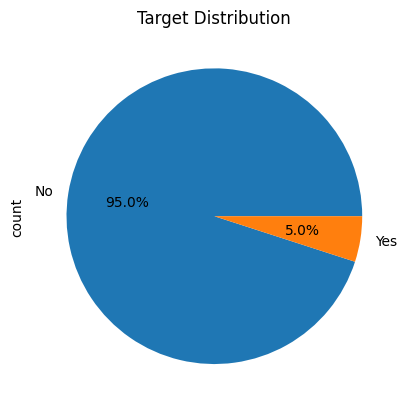

In [272]:
from enum import auto
df['target'].value_counts().plot(kind='pie',autopct='%1.1f%%',labels=['No','Yes'])
plt.title('Target Distribution')
plt.show()

In [273]:
from sklearn.utils import resample
from imblearn.over_sampling import RandomOverSampler
ros=RandomOverSampler(random_state=42)
x_res,y_res=ros.fit_resample(df.drop('target', axis=1),df['target'])

In [274]:
pd.Series(y_res).value_counts()

,count
target,
0,18814
1,18814


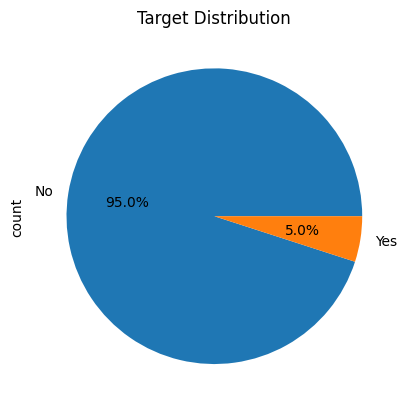

In [275]:
from enum import auto
df['target'].value_counts().plot(kind='pie',autopct='%1.1f%%',labels=['No','Yes'])
plt.title('Target Distribution')
plt.show()

# 🧹Task 14 Class Imbalance

এই Task-এ `target` column-এর **class imbalance** check ও handle করেছি।

* `value_counts()` এবং `normalize=True` দিয়ে class distribution ও percentage check করেছি।
* Bar/Pie Chart দিয়ে imbalance visualize করেছি।
* `RandomOverSampler` ব্যবহার করে minority class **oversample** করেছি।
* `X_res` ও `y_res` তৈরি করে resampled dataset পেয়েছি।
* শেষে `value_counts()` দিয়ে classes balanced হয়েছে কিনা verify করেছি।

**Goal:** Imbalanced target classes-কে balance করে model training-এর জন্য better dataset তৈরি করা।




# **Task 15 Schema / Column Validation**


* Identify bad columns: df.isnull().mean() to see null percentage per column.

*  Set threshold: drop columns with > 50% null values.

* Drop: df.drop`(columns=cols_to_drop, inplace=True)`

*  Validate expected columns: expected_cols = `[employee_id,name,age,salary,...]`
* Check missing: missing = set(expected_cols) - set(df.columns)
* Verify: df.columns to confirm correct schema.




In [279]:
null_perc=df.isnull().mean()

In [282]:
co_to_drop =null_perc[null_perc > 0.50].index

In [283]:
df.drop(columns=co_to_drop,inplace=True)

In [284]:
expected_cols=['employee_id','name','age','salary','join_date','department','gender','country','city','weight_kg','is_active','review','price','target']

In [285]:
missing=set(expected_cols) - set(df.columns)

In [286]:
missing

set()

In [287]:
df.columns

Index(['employee_id', 'name', 'age', 'salary', 'join_date', 'department',
       'gender', 'country', 'city', 'weight_kg', 'is_active', 'review',
       'price', 'target'],
      dtype='object')

In [288]:
df.to_csv('Cleaned_dataset.csv',index=False)

# 🧹 Task 15: Schema / Column Validation

এই Task-এ dataset-এর **column quality ও schema** validate করেছি।

* `df.isnull().mean()` দিয়ে প্রতিটি column-এর missing value percentage check করেছি।
* যেসব column-এ **50%-এর বেশি null** ছিল, সেগুলো identify করে drop করেছি।
* `expected_cols` দিয়ে dataset-এ প্রয়োজনীয় columns আছে কিনা check করেছি।
* `set()` ব্যবহার করে কোনো expected column missing আছে কিনা identify করেছি।
* শেষে `df.columns` দিয়ে final schema verify করেছি।

**Goal:** অপ্রয়োজনীয় high-null columns remove করে dataset-এর expected schema ঠিক রাখা।
